# Dataset Generation for Policy Distillation

Builds the offline (state, action, logit) dataset used to distill the
four SAC experts into a single E-conditioned student via Behavioral
Cloning.

**Input** (per expert)
- `best_model.zip` and `vecnorm_best.pkl` from the expert's training
  output folder.

**Output**
`distillation_data/distillation_dataset.npz` containing
- `X`         shape `(N, 45)`: env observation (44) concatenated with `E_norm` (1).
- `y_action`  shape `(N, 12)`: deterministic expert action, post-tanh, used for MSE BC loss.
- `y_logit`   shape `(N, 12)`: pre-tanh logit (clamped to +/-5), used for KL-style distillation.

`distillation_data/metadata.json` with per-expert acceptance / rejection
counts and logit statistics.

**Collection strategy**
1. Each expert is rolled out under **two separate regimes**: `dynamic`
   (`p_static=0.0`, target moving) and `static` (`p_static=1.0`,
   target stationary). Separating them gives us explicit control over
   the dyn/stat mix (here 150/50 = 75% / 25% per expert).
2. Episodes are **filtered on `on_goal_fraction`** — only episodes
   above a quality threshold are kept. The threshold is **per-expert**:
   more permissive for the soft expert (less performant) to avoid
   over-rejecting and skewing the dataset toward stiffer values.
3. Both the post-tanh action and the pre-tanh logit (clamped to +/-5)
   are recorded. The logit is the cleaner regression target: actions
   near +/-1 sit in tanh's saturation zone where gradients vanish,
   whereas logits give a well-defined regression signal.

After collection all samples are concatenated, shuffled, and saved.


In [1]:
import numpy as np
import json
from pathlib import Path
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from rod_tracking_env import RodTrackingEnv
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch

In [3]:
# Trained experts
EXPERTS = {
    5e6: {
        "model": "results_expert_E5e6_v28/best_model.zip",
        "vecnorm": "results_expert_E5e6_v28/vecnorm_best.pkl",
    },
    7.5e6: {"model": "results_expert_E7.5e6_v27/best_model.zip",
            "vecnorm": "results_expert_E7.5e6_v27/vecnorm_best.pkl"
    },
    1e7: {
        "model": "results_expert_E1e7_v27/best_model.zip",
        "vecnorm": "results_expert_E1e7_v27/vecnorm_best.pkl",
    },
    2e7: {
        "model": "results_expert_E2e7_v27/best_model.zip",
        "vecnorm": "results_expert_E2e7_v27/vecnorm_best.pkl",
    },
}

# Env parameters — MUST match the training distributi
ENV_BASE = {
    'n_elem': 20,
    'sim_dt': 2.0e-4,
    'num_steps_per_update': 7,
    'base_length': 1.0,
    'base_radius': 0.05,
    'density': 1000.0,
    'NU': 11.0,
    'n_control_points': 6,
    'alpha': 75.0,
    'max_rate_of_change_of_activation': np.inf,
    'target_v_max': 0.50,
    'boundary': (-0.35, 0.35, 0.90, 1.0, -0.35, 0.35),
    'final_time': 10.0,
    'success_threshold': 0.01,
    'w_dist': 2.0,
    'w_precision': 5.0,
    'w_progress': 1.0,
    'w_smoothness': 0.03,
    'sigma_mult': 1.5,
    'sigma_floor': 0.01,
}

# Episodes per expert
N_DYNAMIC = 150
N_STATIC  = 50

# Quality filters (per expert, per regime)
MIN_ON_GOAL_DYNAMIC = {
    5e6: 0.30,
    7.5e6: 0.50,
    1e7: 0.50,
    2e7: 0.70,
}
MIN_ON_GOAL_STATIC = {
    5e6: 0.70,
    7.5e6: 0.80,
    1e7: 0.80,
    2e7: 0.80,
}

OUTPUT_DIR = Path("distillation_data")

# E_norm = (log10(E) - log10(E_MIN)) / (log10(E_MAX) - log10(E_MIN))
# Log-spacing is used because Young's modulus spans more than half a
# decade and behavior is approximately scale-invariant on log scale.
E_MIN = 5e6
E_MAX = 2e7


In [4]:
# ======================================================================
# UTILITIES
# ======================================================================

def normalize_E(E: float) -> float:
    """Log-scale normalize a Young's modulus value to [0, 1].

    The expert's stiffness is encoded as the 45th feature of the
    student input. Log-scale is used because E spans more than a
    decade and dynamics are roughly scale-invariant under log(E).
    """
    log_E   = np.log10(E)
    log_min = np.log10(E_MIN)
    log_max = np.log10(E_MAX)
    return (log_E - log_min) / (log_max - log_min)


class ExpertWrapper:
    """Wraps a SAC expert and its VecNormalize stats for distillation rollouts.

    The wrapper exposes `predict_with_logit(obs)` which returns BOTH:
      - the deterministic post-tanh action (for env stepping and as a
        regression target via MSE BC), and
      - the pre-tanh logit (clamped to +/-5) which is the cleaner
        regression target for the student because it avoids tanh's
        saturated regions.

    Why the mean instead of a sample
    --------------------------------
    SAC is a stochastic policy: at training time it samples
        action_raw ~ Normal(mean, std)
        action     = tanh(action_raw)
    For distillation we want a clean, repeatable teaching signal, so
    we use the policy's mean directly (no sampling noise). This is
    equivalent to calling SAC with `deterministic=True` but exposes
    the pre-tanh `mean_logit` which `model.predict(...)` would drop.
    """

    def __init__(self, model_path, vecnorm_path, young_modulus):
        self.E = young_modulus
        self.model = SAC.load(model_path, device="cuda")

        env_params = {**ENV_BASE, 'young_modulus': young_modulus, 'p_static': 0.0}
        dummy_env = DummyVecEnv([lambda: RodTrackingEnv(**env_params)])
        self.vec_norm = VecNormalize.load(vecnorm_path, dummy_env)
        self.vec_norm.training = False
        self.vec_norm.norm_reward = False

        self.model.policy.set_training_mode(False)

        print(f"  Loaded expert E={young_modulus:.0e} | device={self.model.device}")

    def predict_with_logit(self, obs: np.ndarray):
        """Return (action_post_tanh, logit_pre_tanh) for a single obs.

        Both arrays are 1-D length action_dim. The logit is clamped to
        +/-5 because beyond that magnitude tanh saturates and the BC
        loss would chase information that doesn't change the resulting
        action.
        """
        norm_obs = self.vec_norm.normalize_obs(obs.reshape(1, -1))
        obs_tensor = self.model.policy.obs_to_tensor(norm_obs)[0]

        # Walk the SAC actor manually to grab the pre-tanh mean.
        with torch.no_grad():
            features = self.model.policy.actor.extract_features(
                obs_tensor, self.model.policy.actor.features_extractor
            )
            latent_pi = self.model.policy.actor.latent_pi(features)
            mean_logit = self.model.policy.actor.mu(latent_pi)      # pre-tanh
            action = torch.tanh(mean_logit)                         # post-tanh

        # Clip stored logit to a usable range.
        logit = torch.clamp(mean_logit, -5.0, 5.0)

        return action.cpu().numpy().flatten(), logit.cpu().numpy().flatten()

In [5]:
def collect_regime(expert, young_modulus, n_episodes, p_static,
                   min_on_goal, regime_name):
    """Collect `n_episodes` accepted episodes for one regime (dynamic or static).

    Parameters
    ----------
    expert        : ExpertWrapper
    young_modulus : float, used to compute E_norm and to set up the env
    n_episodes    : int, number of ACCEPTED episodes to collect
    p_static      : float, 0.0 -> pure dynamic, 1.0 -> pure static
    min_on_goal   : float, quality threshold (episodes below are discarded)
    regime_name   : str, used only as a label in the progress bar

    Returns
    -------
    X       : (n_samples, 45) float32 — obs (44) || E_norm (1)
    actions : (n_samples, 12) float32 — deterministic post-tanh actions
    logits  : (n_samples, 12) float32 — clamped pre-tanh logits
    stats   : dict with `accepted`, `rejected`, `n_samples`
    """

    env_params = {**ENV_BASE, 'young_modulus': young_modulus, 'p_static': p_static}
    env = RodTrackingEnv(**env_params)
    E_norm = normalize_E(young_modulus)

    all_obs    = []
    all_action = []
    all_logit  = []
    accepted   = 0
    rejected   = 0

    pbar = tqdm(total=n_episodes, desc=f"{regime_name} E={young_modulus:.0e}")

    while accepted < n_episodes:
        obs, _ = env.reset()
        ep_obs, ep_action, ep_logit = [], [], []
        done = False

        while not done:
            action, logit = expert.predict_with_logit(obs)
            obs_aug = np.concatenate([obs, [E_norm]])
            ep_obs.append(obs_aug)
            ep_action.append(action)
            ep_logit.append(logit)

            obs, _, terminated, truncated, info = env.step(action)
            done = terminated or truncated

        # Quality filter: accept or reject the WHOLE episode based on
        # its final on_goal_fraction.
        on_goal = info.get("on_goal_fraction", 0.0)

        if on_goal >= min_on_goal:
            all_obs.extend(ep_obs)
            all_action.extend(ep_action)
            all_logit.extend(ep_logit)
            accepted += 1
            pbar.update(1)
            pbar.set_postfix(on_goal=f"{on_goal:.2f}", rej=rejected)
        else:
            rejected += 1

    pbar.close()
    env.close()

    return (
        np.array(all_obs, dtype=np.float32),
        np.array(all_action, dtype=np.float32),
        np.array(all_logit, dtype=np.float32),
        {"accepted": accepted, "rejected": rejected, "n_samples": len(all_obs)},
    )

In [6]:
def generate_dataset():
    """Loop over all experts, collect dyn+stat, save merged dataset."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    all_X        = []
    all_y_action = []
    all_y_logit  = []
    metadata     = {"experts": {}}

    for E, config in EXPERTS.items():
        print(f"\n{'='*60}\n  Expert E={E:.0e}\n{'='*60}")
        expert = ExpertWrapper(config["model"], config["vecnorm"], E)

        # Dynamic regime (target moving)
        X_dyn, y_a_dyn, y_l_dyn, stats_dyn = collect_regime(
            expert, E, N_DYNAMIC, p_static=0.0,
            min_on_goal=MIN_ON_GOAL_DYNAMIC[E],
            regime_name="dynamic",
        )

        # Static regime (target frozen)
        X_stat, y_a_stat, y_l_stat, stats_stat = collect_regime(
            expert, E, N_STATIC, p_static=1.0,
            min_on_goal=MIN_ON_GOAL_STATIC[E],
            regime_name="static ",
        )

        # Concatenate dyn + stat for this expert.
        X_exp   = np.concatenate([X_dyn,  X_stat],  axis=0)
        y_a_exp = np.concatenate([y_a_dyn, y_a_stat], axis=0)
        y_l_exp = np.concatenate([y_l_dyn, y_l_stat], axis=0)

        all_X.append(X_exp)
        all_y_action.append(y_a_exp)
        all_y_logit.append(y_l_exp)

        # Print and store per-expert diagnostics.
        print(f"  Total for E={E:.0e}: {len(X_exp):,} samples "
              f"({stats_dyn['n_samples']:,} dyn + {stats_stat['n_samples']:,} stat)")
        print(f"  Logit stats: mean={y_l_exp.mean():.2f}, "
              f"std={y_l_exp.std():.2f}, max_abs={np.max(np.abs(y_l_exp)):.2f}")

        sat = float(np.mean(np.abs(y_a_exp) > 0.95))
        print(f"  Action saturation |a|>0.95: {sat*100:.1f}%")

        metadata["experts"][f"E_{E:.0e}"] = {
            "E": float(E),
            "E_norm": float(normalize_E(E)),
            "dynamic": stats_dyn,
            "static":  stats_stat,
            "total_samples": len(X_exp),
            "logit_mean": float(y_l_exp.mean()),
            "logit_std":  float(y_l_exp.std()),
            "action_saturation": sat,
        }

    # Merge all experts
    X_full   = np.concatenate(all_X, axis=0)
    y_action = np.concatenate(all_y_action, axis=0)
    y_logit  = np.concatenate(all_y_logit, axis=0)

    # Shuffle
    idx = np.random.permutation(len(X_full))
    X_full, y_action, y_logit = X_full[idx], y_action[idx], y_logit[idx]

    # Save
    np.savez(
        OUTPUT_DIR / "distillation_dataset.npz",
        X=X_full, y_action=y_action, y_logit=y_logit,
    )

    metadata["total_samples"] = len(X_full)
    metadata["obs_dim"]       = int(X_full.shape[1])   # 45 (44 + E_norm)
    metadata["action_dim"]    = int(y_action.shape[1])  # 12
    metadata["N_DYNAMIC_per_expert"] = N_DYNAMIC
    metadata["N_STATIC_per_expert"]  = N_STATIC

    with open(OUTPUT_DIR / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2)

    print(f"\n{'='*60}\n  DATASET GENERATED v3\n{'='*60}")
    print(f"  X:        {X_full.shape}   (obs_44 + E_norm)")
    print(f"  y_action: {y_action.shape} (post-tanh)")
    print(f"  y_logit:  {y_logit.shape}  (pre-tanh)")
    for E in EXPERTS:
        m = metadata["experts"][f"E_{E:.0e}"]
        print(f"  E={E:.0e}: {m['total_samples']:,} tot  "
              f"({m['dynamic']['n_samples']:,} dyn + {m['static']['n_samples']:,} stat)  "
              f"| saturation={m['action_saturation']*100:.1f}%")


if __name__ == "__main__":
    generate_dataset()


  Expert E=5.0e+06
  Loaded expert E=5.0e+06 | device=cuda


static  E=5.0e+06: 100%|██████████| 60/60 [1:28:47<00:00, 88.79s/it, on_goal=0.75, rej=725] 


  Total for E=5.0e+06: 1,428,400 samples (999,880 dyn + 428,520 stat)
  Logit stats: mean=0.00, std=1.17, max_abs=5.00
  Action saturation |a|>0.95: 11.4%

  Expert E=7.5e+06
  Loaded expert E=7.5e+06 | device=cuda


static  E=7.5e+06: 100%|██████████| 60/60 [32:12<00:00, 32.21s/it, on_goal=0.97, rej=224]


  Total for E=7.5e+06: 1,428,400 samples (999,880 dyn + 428,520 stat)
  Logit stats: mean=-0.00, std=1.13, max_abs=5.00
  Action saturation |a|>0.95: 10.1%

  Expert E=1.0e+07
  Loaded expert E=1.0e+07 | device=cuda


static  E=1.0e+07: 100%|██████████| 60/60 [22:35<00:00, 22.59s/it, on_goal=0.96, rej=139]


  Total for E=1.0e+07: 1,428,400 samples (999,880 dyn + 428,520 stat)
  Logit stats: mean=-0.00, std=1.14, max_abs=5.00
  Action saturation |a|>0.95: 10.1%

  Expert E=2.0e+07
  Loaded expert E=2.0e+07 | device=cuda


static  E=2.0e+07: 100%|██████████| 60/60 [14:25<00:00, 14.43s/it, on_goal=0.95, rej=63]


  Total for E=2.0e+07: 1,428,400 samples (999,880 dyn + 428,520 stat)
  Logit stats: mean=0.02, std=1.17, max_abs=5.00
  Action saturation |a|>0.95: 10.8%

  DATASET GENERATO v4
  X:        (5713600, 45)   (obs_44 + E_norm)
  y_action: (5713600, 12) (post-tanh)
  y_logit:  (5713600, 12)  (pre-tanh, per KL/NLL loss)
  E=5.0e+06: 1,428,400 tot  (999,880 dyn + 428,520 stat)  | saturation=11.4%
  E=7.5e+06: 1,428,400 tot  (999,880 dyn + 428,520 stat)  | saturation=10.1%
  E=1.0e+07: 1,428,400 tot  (999,880 dyn + 428,520 stat)  | saturation=10.1%
  E=2.0e+07: 1,428,400 tot  (999,880 dyn + 428,520 stat)  | saturation=10.8%


## Dataset inspection

Quick diagnostics on the saved `distillation_dataset.npz`:

1. Shape / NaN sanity check
2. Action and logit statistics (range, saturation, per-expert stats)
3. Per-expert balance (how many samples each expert contributed)
4. Distribution plots (first 3 action and logit dimensions)
5. PCA cluster-separability ratio — checks whether the obs+E_norm
   feature space is informative enough to distinguish stiffness
   regimes. A low ratio (<0.5) would indicate the student might
   struggle to condition on E.



DATASET ANALYSIS: distillation_data_v4/distillation_dataset.npz
Input X: (5713600, 45) | y_action: (5713600, 12)
y_logit: (5713600, 12)
NaN in X: False | NaN in y_action: False

--- Statistiche Azioni e Logit ---
Action (post-tanh) -> Min: -1.000, Max: 1.000
Action saturation (|a| > 0.95): 10.6%
Logit  (pre-tanh)  -> Min: -5.000, Max: 5.000
Logit Mean: 0.004, Std: 1.149

--- Logit stats per esperto ---
  E_norm=0.000: logit mean=+0.004  std=1.170  sat=11.4%
  E_norm=0.292: logit mean=-0.005  std=1.126  sat=10.1%
  E_norm=0.500: logit mean=-0.000  std=1.135  sat=10.1%
  E_norm=1.000: logit mean=+0.016  std=1.165  sat=10.8%

--- Bilanciamento per Esperto ---
  E_norm=0.000: 1,428,400 samples (25.0%)
  E_norm=0.292: 1,428,400 samples (25.0%)
  E_norm=0.500: 1,428,400 samples (25.0%)
  E_norm=1.000: 1,428,400 samples (25.0%)


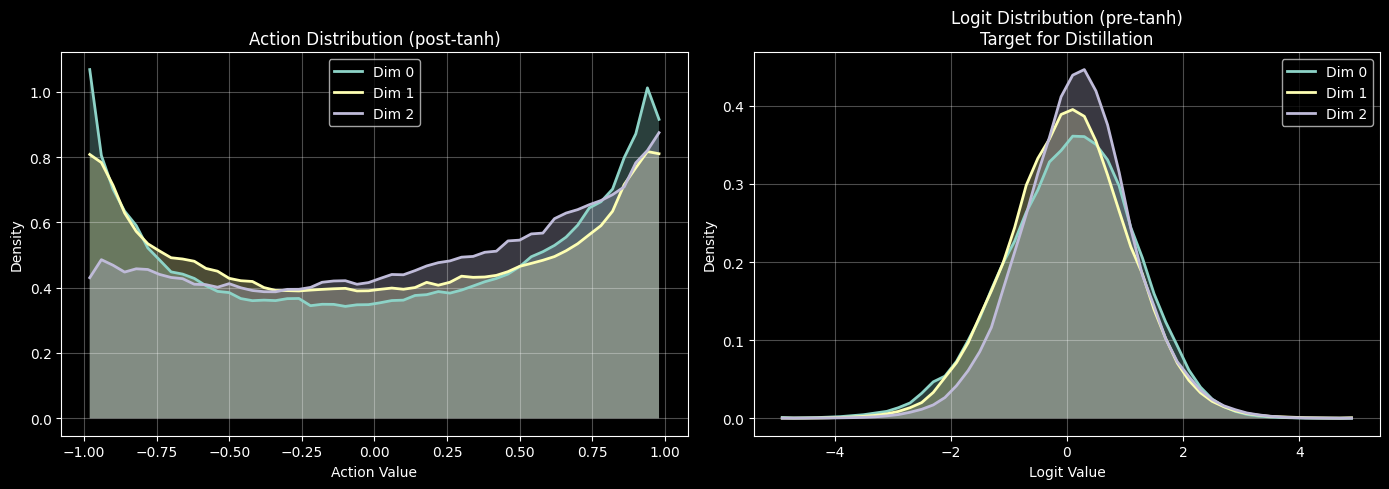


Calcolo PCA sulle feature...

--- Separabilità cluster PCA ---
  E_norm=0.000: centroid=(+0.02, -0.03)  spread=0.71
  E_norm=0.292: centroid=(-0.03, +0.03)  spread=0.73
  E_norm=0.500: centroid=(+0.03, +0.00)  spread=0.74
  E_norm=1.000: centroid=(-0.02, +0.00)  spread=0.77
  Mean inter-centroid dist: 0.05
  Mean intra-cluster spread: 0.74
  Separability ratio: 0.06  (BASSA — lo student potrebbe non distinguere E)


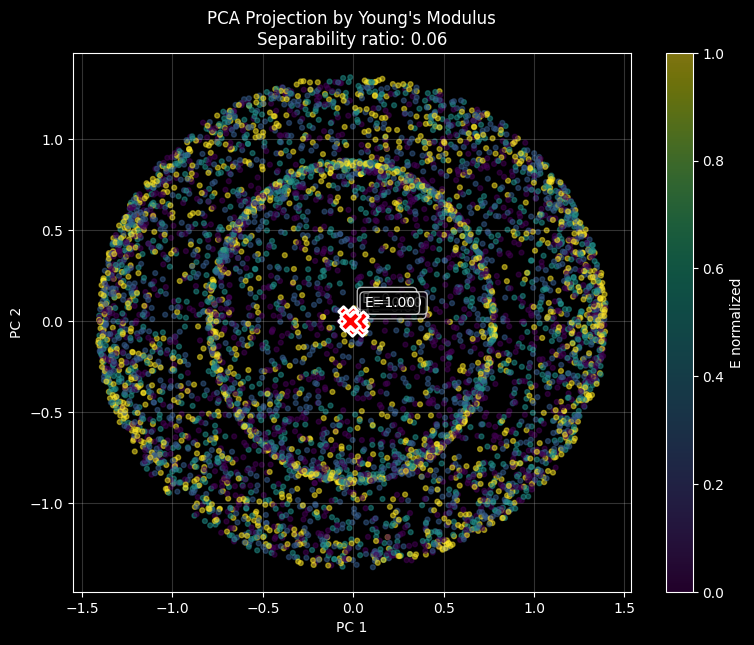

In [10]:
def dataset_inspection(file_path="distillation_data/distillation_dataset.npz"):
    """Inspect the saved distillation dataset and produce diagnostic plots."""
    print(f"\n{'='*60}\nDATASET ANALYSIS: {file_path}\n{'='*60}")

    # Safe load
    try:
        data = np.load(file_path)
        X        = data['X']
        y_action = data.get('y_action', data.get('y'))
        has_logit = 'y_logit' in data
        if has_logit:
            y_logit = data['y_logit']
    except FileNotFoundError:
        print(f"Errore: File '{file_path}' non trovato.")
        return

    print(f"Input X: {X.shape} | y_action: {y_action.shape}")
    if has_logit:
        print(f"y_logit: {y_logit.shape}")
    print(f"NaN in X: {np.isnan(X).any()} | NaN in y_action: {np.isnan(y_action).any()}")

    # Action and logit statistics
    print(f"\n--- Action / logit statistics ---")
    print(f"Action (post-tanh) -> Min: {y_action.min():.3f}, Max: {y_action.max():.3f}")
    sat = np.mean(np.abs(y_action) > 0.95) * 100
    print(f"Action saturation (|a| > 0.95): {sat:.1f}%")

    if has_logit:
        print(f"Logit  (pre-tanh)  -> Min: {y_logit.min():.3f}, Max: {y_logit.max():.3f}")
        print(f"Logit Mean: {y_logit.mean():.3f}, Std: {y_logit.std():.3f}")

        # Per-expert logit stats. Identifies experts whose teaching
        # signal is unusually noisy or saturated.
        E_norm = X[:, -1]
        unique_E = np.unique(E_norm)
        print(f"\n--- Per-expert logit statso ---")
        for e in unique_E:
            mask = E_norm == e
            print(f"  E_norm={e:.3f}: logit mean={y_logit[mask].mean():+.3f}  "
                  f"std={y_logit[mask].std():.3f}  "
                  f"sat={np.mean(np.abs(y_action[mask]) > 0.95)*100:.1f}%")

    # Per-expert balance
    E_norm   = X[:, -1]
    unique_E = np.unique(E_norm)
    print(f"\n--- Per-expert balance ---")
    for e in unique_E:
        n = np.sum(E_norm == e)
        print(f"  E_norm={e:.3f}: {n:,} samples ({100*n/len(X):.1f}%)")

    # Action / logit distribution plots
    fig, axes = plt.subplots(1, 2 if has_logit else 1, figsize=(14 if has_logit else 7, 5))
    if not has_logit:
        axes = [axes]

    ax = axes[0]
    for i in range(min(3, y_action.shape[1])):
        density, bins = np.histogram(y_action[:, i], bins=50, density=True)
        centers = (bins[:-1] + bins[1:]) / 2
        ax.plot(centers, density, label=f'Dim {i}', lw=2)
        ax.fill_between(centers, density, alpha=0.3)
    ax.set_title("Action Distribution (post-tanh)")
    ax.set_xlabel("Action Value"); ax.set_ylabel("Density")
    ax.legend(); ax.grid(True, alpha=0.3)

    if has_logit:
        ax = axes[1]
        for i in range(min(3, y_logit.shape[1])):
            density, bins = np.histogram(y_logit[:, i], bins=50, density=True)
            centers = (bins[:-1] + bins[1:]) / 2
            ax.plot(centers, density, label=f'Dim {i}', lw=2)
            ax.fill_between(centers, density, alpha=0.3)
        ax.set_title("Logit Distribution (pre-tanh)\nTarget for Distillation")
        ax.set_xlabel("Logit Value"); ax.set_ylabel("Density")
        ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 5. PCA + cluster separability
    print("\nCalcolo PCA sulle feature...")
    X_features = X[:, :-1]

    subset_size = 6000
    if len(X_features) > subset_size:
        idx = np.random.choice(len(X_features), subset_size, replace=False)
        X_sub = X_features[idx]
        colors = E_norm[idx]
    else:
        X_sub = X_features
        colors = E_norm

    X_sub_centered = X_sub - np.mean(X_sub, axis=0)

    try:
        U, S, Vt = np.linalg.svd(X_sub_centered, full_matrices=False)
        X_pca = X_sub_centered @ Vt[:2].T

        # For each E, compute the 2-D centroid and average spread in
        # PCA space. The "separability ratio" = (mean inter-centroid
        # distance) / (mean intra-cluster spread)
        print(f"\n--- PCA cluster separability ---")
        centroids, spreads = {}, {}
        for e in unique_E:
            mask = colors == e
            pts = X_pca[mask]
            centroids[e] = pts.mean(axis=0)
            spreads[e]   = pts.std(axis=0).mean()
            print(f"  E_norm={e:.3f}: centroid=({centroids[e][0]:+.2f}, "
                  f"{centroids[e][1]:+.2f})  spread={spreads[e]:.2f}")

        # Aggregate distance vs spread.
        dists = []
        keys = list(centroids.keys())
        for i in range(len(keys)):
            for j in range(i+1, len(keys)):
                dists.append(np.linalg.norm(centroids[keys[i]] - centroids[keys[j]]))
        mean_dist   = np.mean(dists)
        mean_spread = np.mean(list(spreads.values()))
        ratio = mean_dist / mean_spread if mean_spread > 0 else float('inf')
        print(f"  Mean inter-centroid dist: {mean_dist:.2f}")
        print(f"  Mean intra-cluster spread: {mean_spread:.2f}")
        print(f"  Separability ratio: {ratio:.2f}")

        # PCA scatter with E-based coloring and centroid markers.
        plt.figure(figsize=(9, 7))
        scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors,
                              cmap='viridis', alpha=0.5, s=12)
        plt.colorbar(scatter, label='E normalized')
        for e, c in centroids.items():
            plt.scatter(c[0], c[1], c='red', s=200, marker='X',
                        edgecolors='white', linewidths=2, zorder=10)
            plt.annotate(f'E={e:.2f}', c, textcoords="offset points",
                         xytext=(10, 10), fontsize=10, color='white',
                         bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        plt.title(f"PCA Projection by Young's Modulus\nSeparability ratio: {ratio:.2f}")
        plt.xlabel("PC 1"); plt.ylabel("PC 2")
        plt.grid(True, alpha=0.2)
        plt.show()

    except Exception as e:
        print(f"PCA computation / plot failed: {e}")

if __name__ == "__main__":
    dataset_inspection()